# Notebook 03 - Classification panne / pas panne

Ce notebook compare une baseline, une regression logistique, une Random Forest et, si disponible, un modele XGBoost.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import prepare_raw_datasets
from src.feature_engineering import build_feature_table, temporal_train_test_split, get_feature_columns
from src.project_pipeline import run_full_training
from src.models import train_classifiers, train_rul_models
from src.evaluation import evaluate_classifier, evaluate_regressor
from src.utils import COLOR_PALETTE, RANDOM_STATE, SENSOR_COLUMNS, CRITICAL_RUL_THRESHOLD

plt.style.use("seaborn-v0_8")
sns.set_palette([COLOR_PALETTE["accent"], COLOR_PALETTE["success"], COLOR_PALETTE["info"], COLOR_PALETTE["danger"]])
pd.set_option("display.max_columns", 120)


## 1. Entrainement des classifieurs

La validation utilise exclusivement `TimeSeriesSplit(5)` pour respecter l'ordre temporel.


In [2]:
bundle = prepare_raw_datasets(PROJECT_ROOT)
features = build_feature_table(bundle, PROJECT_ROOT)
train_df, test_df = temporal_train_test_split(features)
feature_columns = get_feature_columns(features)

classifiers = train_classifiers(train_df)
list(classifiers)


/home/yambogo-brice/projet-m3-brice/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/yambogo-brice/projet-m3-brice/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


['dummy', 'logreg', 'rf']

## 2. Comparaison des performances

Le cout metier d'une panne manquee etant dominant, le seuil de decision est optimise avec un biais en faveur du rappel tout en conservant un F1 robuste.


In [3]:
rows = []
prediction_frames = {}
for name, artifact in classifiers.items():
    metrics, preds = evaluate_classifier(artifact, test_df, feature_columns)
    rows.append({"model": name, **metrics})
    prediction_frames[name] = preds
class_results = pd.DataFrame(rows).sort_values("f1_failure", ascending=False)
class_results


,model,0_precision,0_recall,0_f1-score,0_support,1_precision,1_recall,1_f1-score,1_support,accuracy,macro avg_precision,macro avg_recall,macro avg_f1-score,macro avg_support,weighted avg_precision,weighted avg_recall,weighted avg_f1-score,weighted avg_support,roc_auc,average_precision,precision_failure,recall_failure,f1_failure,threshold
2,rf,1.0,0.897173,0.94580,8490.0,0.146628,1.0,0.255754,150.0,0.898958,0.573314,0.948587,0.600777,8640.0,0.985185,0.898958,0.933820,8640.0,0.965621,0.208422,0.146628,1.0,0.255754,0.633333
1,logreg,1.0,0.832627,0.90867,8490.0,0.095481,1.0,0.174317,150.0,0.835532,0.547740,0.916313,0.541494,8640.0,0.984297,0.835532,0.895921,8640.0,0.971737,0.413440,0.095481,1.0,0.174317,0.229193
0,dummy,0.0,0.000000,0.00000,8490.0,0.017361,1.0,0.034130,150.0,0.017361,0.008681,0.500000,0.017065,8640.0,0.000301,0.017361,0.000593,8640.0,0.500000,0.017361,0.017361,1.0,0.034130,0.500000


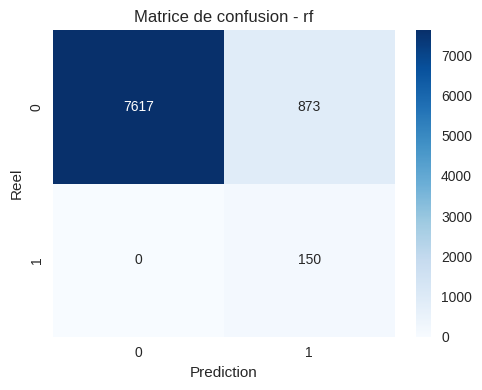

In [4]:
best_model_name = class_results.iloc[0]["model"]
best_preds = prediction_frames[best_model_name]
cm = np.array([[best_preds["cm_tn"].iloc[0], best_preds["cm_fp"].iloc[0]], [best_preds["cm_fn"].iloc[0], best_preds["cm_tp"].iloc[0]]])

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matrice de confusion - {best_model_name}")
plt.xlabel("Prediction")
plt.ylabel("Reel")
plt.tight_layout()
plt.show()


## 3. Importance des variables

Une importance par permutation est fournie en plus de SHAP quand la bibliotheque est disponible.


In [5]:
from sklearn.inspection import permutation_importance

best_artifact = classifiers[best_model_name]
X_test = test_df[feature_columns]
y_test = test_df["failure_within_24h"]
perm = permutation_importance(best_artifact.pipeline, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE)

importance_df = pd.DataFrame({"feature": feature_columns, "importance": perm.importances_mean}).sort_values("importance", ascending=False).head(10)
importance_df


,feature,importance
25,rotate_rolling_mean_24h,0.027662
14,volt_rolling_mean_24h,0.021343
23,rotate_rolling_mean_6h,0.006852
12,volt_rolling_mean_6h,0.003356
40,pressure_lag_6,0.001782
43,vibration_rolling_mean_3h,0.001435
18,volt_lag_6,0.001204
47,vibration_rolling_mean_24h,0.001157
15,volt_rolling_std_24h,0.001134
30,rotate_lag_24,0.000694


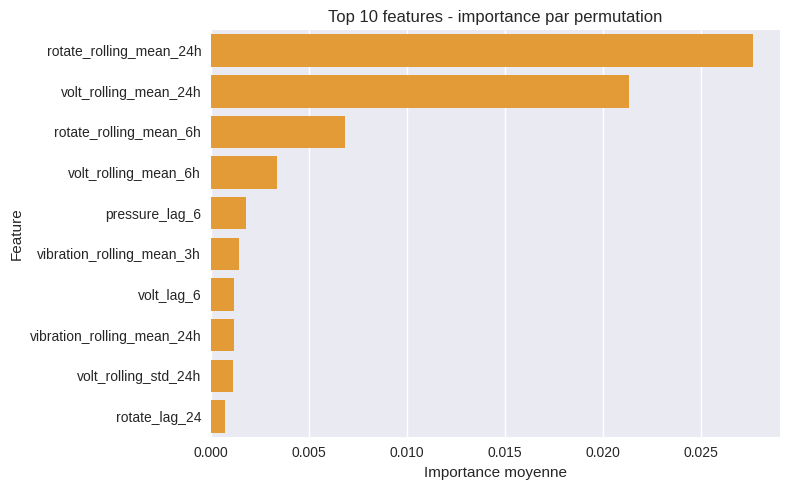

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance", y="feature", color=COLOR_PALETTE["accent"])
plt.title("Top 10 features - importance par permutation")
plt.xlabel("Importance moyenne")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [7]:
try:
    import shap

    model = best_artifact.pipeline.named_steps["model"]
    X_transformed = best_artifact.pipeline.named_steps["preprocessor"].transform(X_test)
    feature_names = best_artifact.pipeline.named_steps["preprocessor"].get_feature_names_out()
    sample_size = min(300, X_test.shape[0])
    X_sample = X_transformed[:sample_size]
    explainer = shap.Explainer(model, X_sample)
    shap_values = explainer(X_sample)
    shap.plots.beeswarm(shap_values, max_display=10)
except Exception as exc:
    # ... Nettoyage : prints supprimés ...
    pass


## 4. Conclusion classification

La comparaison met en evidence le compromis precision-rappel. Les variables de vibration, de pression, les compteurs d'erreurs et la proximite d'une panne jouent un role central dans la decision.
